In [1]:
import xarray as xr
import cftime
import numpy as np
import xarray as xr



In [ ]:
url = "https://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP/.CPC/.CAMS/.anomaly/.temp_9120/dods"
ds = xr.open_dataset(url, decode_times=False)

time_vals = ds["T"].values
units = ds["T"].attrs.get("units", "months since 1960-01-01")
calendar = ds["T"].attrs.get("calendar", "360_day")

if calendar == "360":
    calendar = "360_day"

decoded_time = cftime.num2date(time_vals, units=units, calendar=calendar)

ds = ds.assign_coords(T=("T", decoded_time))

lat_sel = 7.5
lon_sel = 134.5

point = ds.sel(Y=lat_sel, X=lon_sel, method="nearest")
last_time = ds["T"].values[-1]
print("Last time:", last_time)

last_month_ds = ds.sel(T=last_time)

# Extract value for last month at the nearest grid cell to your point
tanom_last = point.sel(T=last_time)["temp_9120"].values.item()

print(f"Temperature anomaly for {last_time:%B %Y}: {tanom_last:.2f} °C")


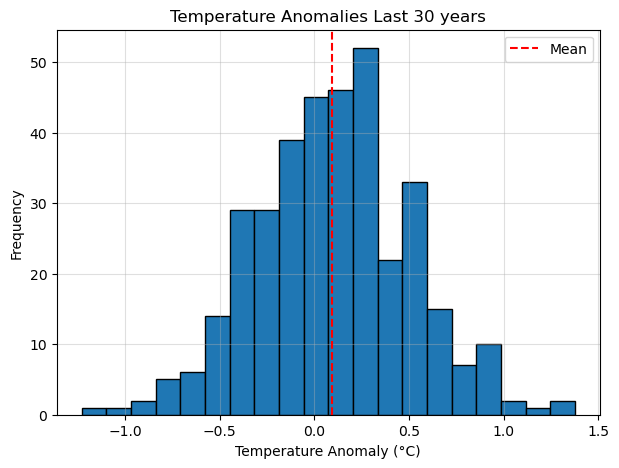

In [ ]:
import xarray as xr
import cftime
import numpy as np
import matplotlib.pyplot as plt

url = "https://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP/.CPC/.CAMS/.anomaly/.temp_9120/dods"
ds = xr.open_dataset(url, decode_times=False)

time_vals = ds["T"].values
units = ds["T"].attrs.get("units", "months since 1960-01-01")
calendar = "360_day"  # Force to 360_day calendar

start_year = 1960
start_month = 1
decoded_time = []
for m in time_vals:
    total_months = int(m)
    year = start_year + total_months // 12
    month = start_month + total_months % 12
    if month > 12:
        month -= 12
        year += 1
    decoded_time.append(cftime.Datetime360Day(year, month, 15))  # mid-month date

ds = ds.assign_coords(T=("T", decoded_time))

# --- Select location ---
lat_sel = 7.5
lon_sel = 134.5
point = ds.sel(Y=lat_sel, X=lon_sel, method="nearest")

# --- Define date range for last 10 years ---
end_date = decoded_time[-1]
start_date = cftime.Datetime360Day(end_date.year - 30, end_date.month, 1)
subset = point.sel(T=slice(start_date, end_date))

# --- Extract anomaly values ---
tanom_values = subset["temp_9120"].values

# --- Plot histogram ---
plt.figure(figsize=(7, 5))
plt.hist(tanom_values, bins=20, edgecolor='black')
plt.axvline(np.nanmean(tanom_values), color='red', linestyle='--', label='Mean')
plt.title(f"Temperature Anomalies Last 30 years")
plt.xlabel("Temperature Anomaly (°C)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


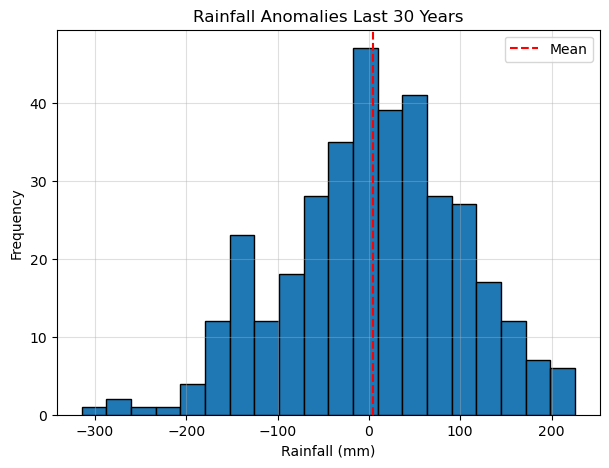

In [ ]:
import xarray as xr
import cftime
import numpy as np
import matplotlib.pyplot as plt

url = "https://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP/.CPC/.CAMS_OPI/.v0208/.anomaly_9120/.prcp/T/%28days%20since%201960-01-01%29streamgridunitconvert/T/differential_mul/T/%28months%20since%201960-01-01%29streamgridunitconvert//units/%28mm/month%29def//long_name/%28Precipitation%20Anomaly%29def/DATA/-500/-450/-400/-350/-300/-250/-200/-150/-100/-50/-25/25/50/100/150/200/250/300/350/400/450/500/VALUES/prcp_anomaly_max500_colors2/dods"
ds = xr.open_dataset(url, decode_times=False)

time_vals = ds["T"].values
units = ds["T"].attrs.get("units", "months since 1960-01-01")
calendar = "360_day" 

start_year = 1960
start_month = 1
decoded_time = []
for m in time_vals:
    total_months = int(m)
    year = start_year + total_months // 12
    month = start_month + total_months % 12
    if month > 12:
        month -= 12
        year += 1
    decoded_time.append(cftime.Datetime360Day(year, month, 15))  # mid-month date

ds = ds.assign_coords(T=("T", decoded_time))

lat_sel = 7.5
lon_sel = 134.5
point = ds.sel(Y=lat_sel, X=lon_sel, method="nearest")

end_date = decoded_time[-1]
start_date = cftime.Datetime360Day(end_date.year - 30, end_date.month, 1)
subset = point.sel(T=slice(start_date, end_date))

tanom_values = subset["aprod"].values

plt.figure(figsize=(7, 5))
plt.hist(tanom_values, bins=20, edgecolor='black')
plt.axvline(np.nanmean(tanom_values), color='red', linestyle='--', label='Mean')
plt.title(f"Rainfall Anomalies Last 30 Years")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


In [2]:
url = "https://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP/.CPC/.CAMS_OPI/.v0208/.anomaly_9120/.prcp/T/%28days%20since%201960-01-01%29streamgridunitconvert/T/differential_mul/T/%28months%20since%201960-01-01%29streamgridunitconvert//units/%28mm/month%29def//long_name/%28Precipitation%20Anomaly%29def/DATA/-500/-450/-400/-350/-300/-250/-200/-150/-100/-50/-25/25/50/100/150/200/250/300/350/400/450/500/VALUES/prcp_anomaly_max500_colors2/dods"
ds = xr.open_dataset(url, decode_times=False)

time_vals = ds["T"].values
units = ds["T"].attrs.get("units", "months since 1960-01-01")
calendar = ds["T"].attrs.get("calendar", "360_day")

if calendar == "360":
    calendar = "360_day"

decoded_time = cftime.num2date(time_vals, units=units, calendar=calendar)

ds = ds.assign_coords(T=("T", decoded_time))

lat_sel = 7.5
lon_sel = 134.5

point = ds.sel(Y=lat_sel, X=lon_sel, method="nearest")
last_time = ds["T"].values[-1]
print("Last time:", last_time)

last_month_ds = ds.sel(T=last_time)

# Extract value for last month at the nearest grid cell to your point
tanom_last = point.sel(T=last_time)["aprod"].values.item()

print(f"Rainfall anomaly for {last_time:%B %Y}: {tanom_last:.2f} mm")


Last time: 2025-10-16 00:00:00
Rainfall anomaly for October 2025: -10.46 mm
